## 1. Importação das Bibliotecas e Dataset

In [76]:
import os

os.environ["KAGGLE_USERNAME"] = "eduardosanzovo"
os.environ["KAGGLE_KEY"] = "b0ac345c494d78f627436504dbf3933a"

!pip install -q kaggle
!kaggle competitions download -c house-prices-advanced-regression-techniques
!unzip -o house-prices-advanced-regression-techniques.zip
!pip install category_encoders

house-prices-advanced-regression-techniques.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  house-prices-advanced-regression-techniques.zip
  inflating: data_description.txt    
  inflating: sample_submission.csv   
  inflating: test.csv                
  inflating: train.csv               


In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from category_encoders import TargetEncoder
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import category_encoders as ce
from sklearn.preprocessing import OrdinalEncoder
from sklearn.neural_network import MLPRegressor


In [78]:
# Dataset
df_train = pd.read_csv("train.csv")
df_train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [79]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [80]:
# Removendo duplicatas e a coluna ID (inútil para ajudar na dedução do SalePrice)
df_train.drop_duplicates()
df_train.drop("Id", axis=1, inplace=True)

# Valores nulos por coluna
nulos = df_train.isna().sum()
print(nulos[nulos > 0])

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64


In [81]:
# Dados auxiliares para tomada de decisão
print(len(df_train[df_train["MasVnrArea"] == 0]))
print(len(df_train[df_train["GarageArea"] == 0]))
print(len(df_train[df_train["PoolArea"] == 0]))
print(len(df_train[df_train["MiscVal"] == 0]))

861
81
1453
1408


In [82]:
# LotFrontage = c1·LotConfig + c2·sqrt(LotArea) + c3
df_lot = df_train[["LotArea", "LotConfig", "LotFrontage"]].copy()

df_lot = df_lot.dropna()

min_area = df_lot["LotArea"].min()
max_area = df_lot["LotArea"].max()

df_lot["LotArea"] = (df_lot["LotArea"] - min_area) / (max_area - min_area)
df_lot["sqrt_LotArea"] = np.sqrt(df_lot["LotArea"])

df_lot = pd.get_dummies(df_lot, columns=["LotConfig"])

y = df_lot["LotFrontage"]
x = df_lot.drop(["LotFrontage", "LotArea"], axis=1)

model = LinearRegression()
model.fit(x, y)

missing_mask = df_train["LotFrontage"].isna()
df_missing = df_train.loc[missing_mask, ["LotArea", "LotConfig"]].copy()

df_missing["LotArea"] = (df_missing["LotArea"] - min_area) / (max_area - min_area)
df_missing["sqrt_LotArea"] = np.sqrt(df_missing["LotArea"])

df_missing = pd.get_dummies(df_missing, columns=["LotConfig"])

df_missing = df_missing.drop("LotArea", axis=1)
df_missing = df_missing.reindex(columns=x.columns, fill_value=0)

predicted_values = model.predict(df_missing)

df_train.loc[missing_mask, "LotFrontage"] = predicted_values

# Alley
df_train["Alley"] = df_train["Alley"].fillna("No alley access")

# MasVnrType
df_train["MasVnrType"] = np.where(df_train["MasVnrArea"] == 0, "No masonry", df_train["MasVnrType"])

# Basement
df_train["BsmtQual"] = df_train["BsmtQual"].fillna("No Basement")
df_train["BsmtCond"] = df_train["BsmtCond"].fillna("No Basement")
df_train["BsmtExposure"] = df_train["BsmtExposure"].fillna("No Basement")
df_train["BsmtFinType1"] = df_train["BsmtFinType1"].fillna("No Basement")
df_train["BsmtFinType2"] = df_train["BsmtFinType2"].fillna("No Basement")

# Electrical
df_train["Electrical"] = df_train["Electrical"].fillna(df_train["Electrical"].mode()[0])

# Fireplace
df_train["FireplaceQu"] = df_train["FireplaceQu"].fillna("No Fireplace")

# Garage
df_train["GarageType"] = df_train["GarageType"].fillna("No Garage")
df_train["GarageYrBlt"] = df_train["GarageYrBlt"].fillna(0)
df_train["GarageFinish"] = df_train["GarageFinish"].fillna("No Garage")
df_train["GarageQual"] = df_train["GarageQual"].fillna("No Garage")
df_train["GarageCond"] = df_train["GarageCond"].fillna("No Garage")

# Pool
df_train["PoolQC"] = df_train["PoolQC"].fillna("No Pool")

# Fence
df_train["Fence"] = df_train["Fence"].fillna("No Fence")

# MiscFeature
df_train["MiscFeature"] = np.where(df_train["MiscVal"] == 0, "No misc", df_train["MiscFeature"])

In [83]:
# Analisando se sobraram valores ausentes
nulos = df_train.isna().sum()
print(nulos[nulos > 0])

MasVnrType    13
MasVnrArea     8
dtype: int64


In [84]:
# Valores faltantes
df_nulos = df_train[df_train["MasVnrType"].isna() | df_train["MasVnrArea"].isna()]
print(df_nulos[["MasVnrType", "MasVnrArea"]])

     MasVnrType  MasVnrArea
234         NaN         NaN
529         NaN         NaN
624         NaN       288.0
650         NaN         NaN
773         NaN         1.0
936         NaN         NaN
973         NaN         NaN
977         NaN         NaN
1230        NaN         1.0
1243        NaN         NaN
1278        NaN         NaN
1300        NaN       344.0
1334        NaN       312.0


In [85]:
# Dados para ajudar na tomada de decisão
print(df_train.groupby("MasVnrType")["MasVnrArea"].agg(["mean", "std"]))

print(df_train["MasVnrType"].mode()[0])

                  mean         std
MasVnrType                        
BrkCmn      247.666667  182.423239
BrkFace     259.592342  215.027938
No masonry    0.000000    0.000000
Stone       241.188976  171.480469
No masonry


In [86]:
# BrkFace é a categoria mais condizente para essas áreas entre 288 e 312
df_train.loc[[624, 1300, 1334], 'MasVnrType'] = 'BrkFace'

# Como "No masonry" é o mais comum, os outros valores ausentes ficaram assim
df_train["MasVnrType"] = df_train["MasVnrType"].fillna("No masonry")

# O resto das áreas assumiu valor zero
df_train["MasVnrArea"] = np.where(df_train["MasVnrType"] == "No masonry", 0, df_train["MasVnrArea"])

In [87]:
# Agora sim acabaram-se os nulos
nulos = df_train.isna().sum()
print(nulos[nulos > 0])

Series([], dtype: int64)


## Tratando Outliers

<Axes: ylabel='SalePrice'>

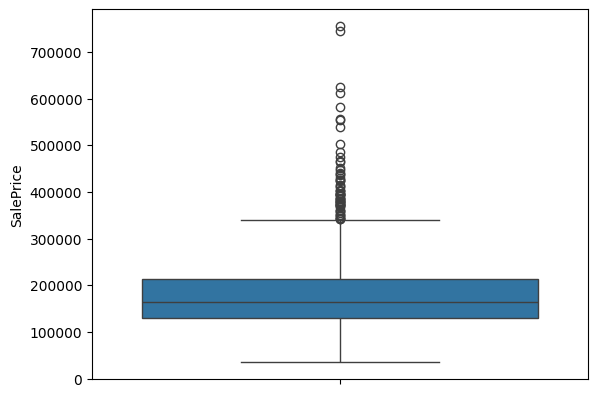

In [88]:
# Vizualização
sns.boxplot(df_train['SalePrice'])

In [89]:
# Calculando quantidade
q1 = df_train["SalePrice"].quantile(0.25)
q3 = df_train["SalePrice"].quantile(0.75)
iqr = q3 - q1

li = q1 - 1.5 * iqr
ls = q3 + 1.5 * iqr

outliers = df_train[(df_train["SalePrice"] >= ls) | (df_train["SalePrice"] <= li)]

# Valor maior que 10%, melhor não tirar tudo
print(f"outliers:{len(outliers)}")

outliers = df_train[df_train["SalePrice"] > 500000]

# Tirando só os valores maiores que 500000
df_train = df_train.drop(outliers.index)

outliers:61




## Modelo de Regressão Linear

In [90]:
# Split
y = df_train["SalePrice"]
x = df_train.drop("SalePrice", axis=1)

x_train, x_val, y_train, y_val = train_test_split(
    x, y, test_size=0.2, random_state=42
)

cat_cols = x_train.select_dtypes(include=["object", "category"]).columns

# Colunas de strings com 10 ou menos elementos únicos sofrem one hot encoding
onehot_cols = [
    col for col in cat_cols
    if x_train[col].nunique() <= 10
]

# Colunas de strings com mais de 10 únicos sofrem target encoding
target_cols = [
    col for col in cat_cols
    if x_train[col].nunique() > 10
]

num_cols = x_train.select_dtypes(exclude=["object", "category"]).columns

preprocess = ColumnTransformer(
    transformers=[
        ("onehot", OneHotEncoder(handle_unknown="ignore"), onehot_cols),
        ("target", TargetEncoder(), target_cols),
        ("num", MinMaxScaler(), num_cols) # Normalização
    ]
)

model = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("regressor", LinearRegression())
    ]
)

# Treinamento
model.fit(x_train, y_train)

# Resultado
score = model.score(x_val, y_val)
print(score)

0.8608070642103068


## Regressão Linear com K-fold

In [91]:
# x e y
y = df_train["SalePrice"]
x = df_train.drop("SalePrice", axis=1)

cat_cols = x.select_dtypes(include=["object", "category"]).columns

# Colunas de strings com 10 ou menos elementos únicos sofrem one hot encoding
onehot_cols = [
    col for col in cat_cols
    if x[col].nunique() <= 10
]

# Colunas de strings com mais de 10 únicos sofrem target encoding
target_cols = [
    col for col in cat_cols
    if x[col].nunique() > 10
]

num_cols = x.select_dtypes(exclude=["object", "category"]).columns

preprocess = ColumnTransformer(
    transformers=[
        ("onehot", OneHotEncoder(handle_unknown="ignore"), onehot_cols),
        ("target", TargetEncoder(), target_cols),
        ("num", MinMaxScaler(), num_cols) # Normalização
    ]
)

model = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("regressor", LinearRegression())
    ]
)

# K-Fold (5-Fold)
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    model,
    x,
    y,
    cv=kf,
    scoring="r2"
)

# Resultados
print("R² médio:", scores.mean())
print("Desvio padrão:", scores.std())

R² médio: 0.7654850855529131
Desvio padrão: 0.12579354534196038


## K-means


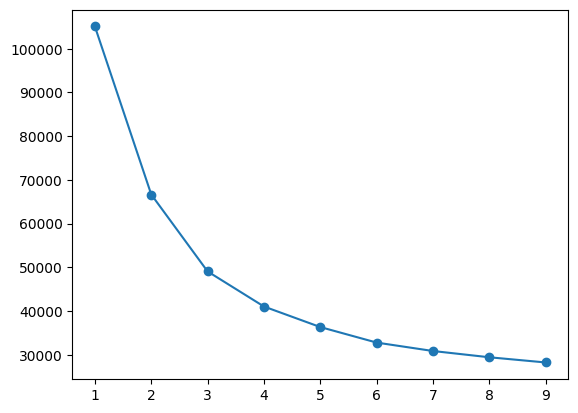

In [92]:
x = df_train.drop("SalePrice", axis=1)

cat_cols = x.select_dtypes(include=["object", "category"]).columns

onehot_cols = [
    col for col in cat_cols
    if x[col].nunique() <= 10
]

target_cols = [
    col for col in cat_cols
    if x[col].nunique() > 10
]

num_cols = x.select_dtypes(exclude=["object", "category"]).columns

preprocess = ColumnTransformer(
    transformers=[
        ("onehot",
         OneHotEncoder(handle_unknown="ignore"),
         onehot_cols),

        ("ordinal",
         OrdinalEncoder(handle_unknown="use_encoded_value",
                        unknown_value=-1),
         target_cols), # Não dá para usar target-encoding em casos não supervisionados

        ("num",
         MinMaxScaler(),
         num_cols)
    ]
)

inercias = []

# Buscando o "cotovelo"
for k in range(1, 10):
    modelo = Pipeline(
        steps=[
            ("preprocess", preprocess),
            ("kmeans", KMeans(
                n_clusters=k,
                random_state=42,
                n_init=10
            ))
        ]
    )

    modelo.fit(x)

    inercias.append(modelo.named_steps["kmeans"].inertia_)

plt.plot(range(1, 10), inercias, marker="o")
plt.show()


## KNN

In [93]:
# Determinando os intervalos
df_train["SalePrice"].describe()

,SalePrice
count,1451.000000
mean,178272.872502
std,71891.119458
min,34900.000000
25%,129900.000000
50%,162500.000000
75%,213000.000000
max,485000.000000


In [94]:
def categoria(preco):
    if preco <= 129900:
        return "Low"
    elif preco <= 162500:
        return "Low-Average"
    elif preco <= 213000:
        return "High-Average"
    else:
        return "High"


df_train["Sale"] = df_train["SalePrice"].apply(categoria)

In [95]:
df_train = df_train.sort_values(by="Sale")

# Separando aproximadamente 80% para treino, todas as classes tem quantias iguais no treinamento
x_train = pd.concat([df_train[0:290], df_train[363:653], df_train[726:1016], df_train[1089:1379]])

y_train = x_train["Sale"]
x_train = x_train.drop(["SalePrice", "Sale"], axis=1)

x_val = pd.concat([df_train[290:363], df_train[653:726], df_train[1016:1089], df_train[1379:1451]])

y_val = x_val["Sale"]
x_val = x_val.drop(["SalePrice", "Sale"], axis=1)

# Lidando com colunas não numéricas
cat_cols = x_train.select_dtypes(include=["object", "category"]).columns

onehot_cols = [
    col for col in cat_cols
    if x_train[col].nunique() <= 10
]

target_cols = [
    col for col in cat_cols
    if x_train[col].nunique() > 10
]

preprocess = ColumnTransformer(
    transformers=[
        ("onehot", OneHotEncoder(handle_unknown="ignore"), onehot_cols),
        ("target", TargetEncoder(), target_cols),
        ("num", StandardScaler(), num_cols)
    ]
)

acc_final = 0
k_final = 0

for k in range(1, 1160):
    model = Pipeline(
        steps=[
            ("preprocess", preprocess),
            ("knn", KNeighborsClassifier(n_neighbors=k))
        ]
    )

    model.fit(x_train, y_train)

    y_pred = model.predict(x_val)

    acc = accuracy_score(y_val, y_pred)

    if acc > acc_final:
        acc_final = acc
        k_final = k

print(f"K = {k_final}, Acurácia = {acc_final:.2f}")

K = 13, Acurácia = 0.78


In [96]:
# Usando só 3 classes agora
def categoria(preco):
    if preco <= 129900:
        return "Low"
    elif preco <= 213000:
        return "Average"
    else:
        return "High"

df_train["Sale"] = df_train["SalePrice"].apply(categoria)

In [97]:
df_train = df_train.sort_values(by="Sale")

# Separando aproximadamente 80% para treino, todas as classes tem quantias iguais no treinamento
x_train = pd.concat([df_train[0:290], df_train[363:944], df_train[1089:1379]])

y_train = x_train["Sale"]
x_train = x_train.drop(["SalePrice", "Sale"], axis=1)

x_val = pd.concat([df_train[290:363],  df_train[944:1089], df_train[1379:1451]])

y_val = x_val["Sale"]
x_val = x_val.drop(["SalePrice", "Sale"], axis=1)

# Lidando com colunas não numéricas
cat_cols = x_train.select_dtypes(include=["object", "category"]).columns

onehot_cols = [
    col for col in cat_cols
    if x_train[col].nunique() <= 10
]

target_cols = [
    col for col in cat_cols
    if x_train[col].nunique() > 10
]

preprocess = ColumnTransformer(
    transformers=[
        ("onehot", OneHotEncoder(handle_unknown="ignore"), onehot_cols),
        ("target", TargetEncoder(), target_cols),
        ("num", StandardScaler(), num_cols)
    ]
)

acc_final = 0
k_final = 0

for k in range(1, 1160):
    model = Pipeline(
        steps=[
            ("preprocess", preprocess),
            ("knn", KNeighborsClassifier(n_neighbors=k))
        ]
    )

    model.fit(x_train, y_train)

    y_pred = model.predict(x_val)

    acc = accuracy_score(y_val, y_pred)

    if acc > acc_final:
        acc_final = acc
        k_final = k

print(f"K = {k_final}, Acurácia = {acc_final:.2f}")

K = 3, Acurácia = 0.81


## MPLRegressor


In [98]:
# Split
y = df_train["SalePrice"]
x = df_train.drop("SalePrice", axis=1)

x_train, x_val, y_train, y_val = train_test_split(
    x, y, test_size=0.2, random_state=42
)

cat_cols = x_train.select_dtypes(include=["object", "category"]).columns

# Colunas de strings com 10 ou menos elementos únicos sofrem one hot encoding
onehot_cols = [
    col for col in cat_cols
    if x_train[col].nunique() <= 10
]

# Colunas de strings com mais de 10 únicos sofrem target encoding
target_cols = [
    col for col in cat_cols
    if x_train[col].nunique() > 10
]

num_cols = x_train.select_dtypes(exclude=["object", "category"]).columns

preprocess = ColumnTransformer(
    transformers=[
        ("onehot", OneHotEncoder(handle_unknown="ignore"), onehot_cols),
        ("target", TargetEncoder(), target_cols),
        ("num", MinMaxScaler(), num_cols) # Normalização
    ]
)

model = Pipeline(
    steps=[
        ("preprocess", preprocess),
        (
            "regressor",
            MLPRegressor(
                hidden_layer_sizes=(32),
                activation="relu",
                solver="adam",
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

# K-Fold (5-Fold)
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    model,
    x,
    y,
    cv=kf,
    scoring="r2"
)

# Resultados
print("R² médio:", scores.mean())
print("Desvio padrão:", scores.std())

R² médio: 0.5089458698038207
Desvio padrão: 0.04845352681802053


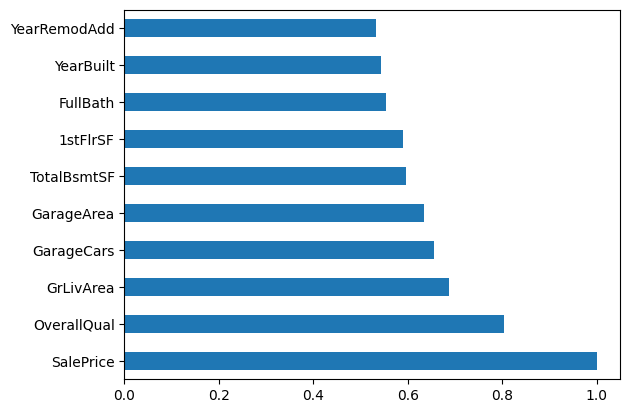

In [100]:
df = df_train

df = df.drop("Sale", axis=1)

cat_cols = df.select_dtypes(include=["object", "category"]).columns
df = pd.get_dummies(df, columns=cat_cols)

corr = df.corr()
corr = corr["SalePrice"]
corr.nlargest(10).plot(kind="barh")
plt.show()